<a href="https://colab.research.google.com/github/bpayton0101/540-ML-Design-Solutions/blob/main/LSTM_DEC_Model_BPayton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM-DEC Model - Optimized

In [1]:
#Code Reference: DialogueActClassification.ipynb - https://github.com/aarushiibisht/Dialogue-Act-Classification-Using-LSTM/blob/master/DialogueActClassification.ipynb

1. Data Preparation and Copying



This section loads the cleaned dataset, which has already undergone initial data cleaning and exploratory data analysis (EDA)

In [3]:
%pip uninstall -y readability-lxml
%pip install readability-lxml

In [4]:
import json
import re

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from pandas.api.types import CategoricalDtype
from readability import Document
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt_tab')
nltk.download('vader_lexicon')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
import pandas as pd

# Load the dataset that has been cleaned and is ready for clustering
df = pd.read_csv('df_copy.csv')

df_ready_for_clustering = df.copy()

print("First 5 rows of the DataFrame ready for clustering:")
print(df_ready_for_clustering.head())

First 5 rows of the DataFrame ready for clustering:
   expected_result  math_level  \
0  Answer Accepted  Elementary   
1  Answer Accepted  Elementary   
2  Answer Accepted  Elementary   
3  Answer Accepted  Elementary   
4  Answer Accepted  Elementary   

                                                data  test_id  \
0  [{'role': 'user', 'content': "I'm struggling w...        1   
1  [{'role': 'user', 'content': 'I need 10 math p...        2   
2  [{'role': 'user', 'content': "What's the produ...        3   
3  [{'role': 'user', 'content': 'Can you assist m...        4   
4  [{'role': 'user', 'content': 'Can you provide ...        5   

                                   conversation_text  \
0  I'm struggling with multiplying decimal number...   
1  I need 10 math problems to work on!\nOf course...   
2  What's the product of 50000 and 50000 in prima...   
3  Can you assist me in solving 2 1/10 divided by...   
4  Can you provide me with 10 exercises on three ...   

               

2. Text Tokenization and Padding



This section prepares the textual data for a neural network model. It involves two key steps: tokenization and padding.

In [6]:
# Reference: Martín Abadi et al., "TensorFlow: A System for Large-Scale Machine Learning." OSDI, 2016.
# Reference: Charles R. Harris et al., "Array programming with NumPy." Nature, vol. 585, no. 7825, pp. 357-362, 2020.

In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Initialize the tokenizer and fit it on the cleaned text data.
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df_ready_for_clustering['conversation_text_clean'])

# Convert the text to sequences of integers.
sequences = tokenizer.texts_to_sequences(df_ready_for_clustering['conversation_text_clean'])

# The 95th percentile is used to capture most of the data without excessive padding.
sequence_lengths = [len(seq) for seq in sequences]
max_length = int(np.percentile(sequence_lengths, 95))

# Pad the sequences so they all have the same length.
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')

print(f"Chosen max_length: {max_length}")
print("Shape of padded sequences:", padded_sequences.shape)

Chosen max_length: 267
Shape of padded sequences: (188, 267)


3. Create the LSTM Encoder Model

This block builds a Keras Sequential model that functions as an LSTM encoder.
* Create a Keras Sequential model.
* Add an Embedding layer.
* Add an LSTM layer. This will be the final layer of our feature extractor.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM

# Define model hyperparameters based on our tokenized data
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 128
lstm_units = 128

# Construct the LSTM encoder model
lstm_encoder_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    LSTM(lstm_units, name='lstm_embedding_layer'),
])

# Display the model's architecture
lstm_encoder_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_embedding_layer (LSTM)     │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

4. Generating LSTM Embeddings

In [9]:
# Generate embeddings
lstm_embeddings = lstm_encoder_model.predict(padded_sequences)

print(f"Shape of generated LSTM embeddings: {lstm_embeddings.shape}")
print("First 5 embeddings (first 10 dimensions):")
print(lstm_embeddings[:5, :10])

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step
Shape of generated LSTM embeddings: (188, 128)
First 5 embeddings (first 10 dimensions):
[[-0.00586957  0.00758946  0.00236512  0.0157108   0.044452   -0.00099048
  -0.0204283  -0.00742587  0.01401732  0.00179814]
 [-0.0058717   0.00759145  0.00236008  0.01571392  0.04445473 -0.00098901
  -0.02042733 -0.00743417  0.01400943  0.00180267]
 [-0.00586957  0.00758946  0.00236512  0.01571079  0.04445199 -0.00099048
  -0.0204283  -0.00742587  0.01401733  0.00179814]
 [-0.00586957  0.00758946  0.00236513  0.01571079  0.044452   -0.00099048
  -0.0204283  -0.00742587  0.01401733  0.00179813]
 [-0.00586957  0.00758946  0.00236512  0.01571079  0.04445199 -0.00099048
  -0.0204283  -0.00742587  0.01401733  0.00179814]]


5. Generating Conversation Embeddings

In [10]:
# Generate conversation embeddings for the entire dataset using the trained LSTM encoder model
conversation_embeddings = lstm_encoder_model.predict(padded_sequences)

print(f"Shape of conversation embeddings: {conversation_embeddings.shape}")
print("First 5 embeddings (first 10 dimensions):")
print(conversation_embeddings[:5, :10])

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
Shape of conversation embeddings: (188, 128)
First 5 embeddings (first 10 dimensions):
[[-0.00586957  0.00758946  0.00236512  0.0157108   0.044452   -0.00099048
  -0.0204283  -0.00742587  0.01401732  0.00179814]
 [-0.0058717   0.00759145  0.00236008  0.01571392  0.04445473 -0.00098901
  -0.02042733 -0.00743417  0.01400943  0.00180267]
 [-0.00586957  0.00758946  0.00236512  0.01571079  0.04445199 -0.00099048
  -0.0204283  -0.00742587  0.01401733  0.00179814]
 [-0.00586957  0.00758946  0.00236513  0.01571079  0.044452   -0.00099048
  -0.0204283  -0.00742587  0.01401733  0.00179813]
 [-0.00586957  0.00758946  0.00236512  0.01571079  0.04445199 -0.00099048
  -0.0204283  -0.00742587  0.01401733  0.00179814]]


6. Determining Optimal Clusters with the Elbow Method

Elbow Method

* Calculate WCSS
* Plot the Results
* Identify the Elbow

In [11]:
# Reference: Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, E. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825-2830.vvv
# Reference: Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90-95.

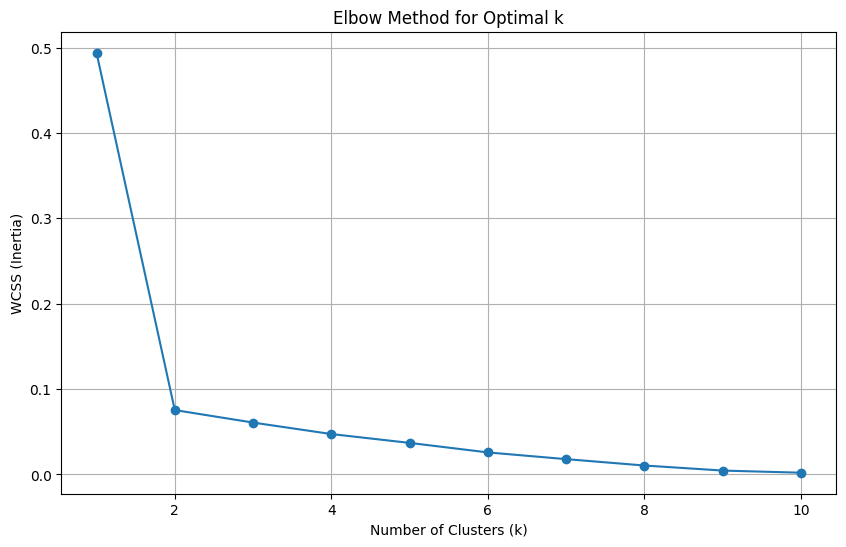

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
k_range = range(1, 11)

# Fit KMeans for a range of k values and calculate the WCSS
for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(conversation_embeddings)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve to visually determine the optimal number of clusters
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

7. Validating Optimal Clusters with the Silhouette Score

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Range of cluster numbers to test, starting from 2
k_range = range(2, 11)
best_score = -1
best_k = -1

# Iterate through the range of k to find the best Silhouette Score
for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    cluster_labels = kmeans.fit_predict(conversation_embeddings)

    # Calculate the Silhouette Score for the current number of clusters
    score = silhouette_score(conversation_embeddings, cluster_labels)

    print(f'Silhouette Score for k={k}: {score:.3f}')

    # Track the best score and corresponding k
    if score > best_score:
        best_score = score
        best_k = k

print(f'\nHighest Silhouette Score is {best_score:.3f} for k={best_k}')

Silhouette Score for k=2: 0.969
Silhouette Score for k=3: 0.951
Silhouette Score for k=4: 0.951
Silhouette Score for k=5: 0.951
Silhouette Score for k=6: 0.953
Silhouette Score for k=7: 0.952
Silhouette Score for k=8: 0.952
Silhouette Score for k=9: 0.951
Silhouette Score for k=10: 0.948

Highest Silhouette Score is 0.969 for k=2


8. Applying KMeans Clustering

In [14]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
df_ready_for_clustering['cluster_labels'] = kmeans.fit_predict(conversation_embeddings)

print("Cluster labels added to DataFrame.")
print(df_ready_for_clustering.head())

Cluster labels added to DataFrame.
   expected_result  math_level  \
0  Answer Accepted  Elementary   
1  Answer Accepted  Elementary   
2  Answer Accepted  Elementary   
3  Answer Accepted  Elementary   
4  Answer Accepted  Elementary   

                                                data  test_id  \
0  [{'role': 'user', 'content': "I'm struggling w...        1   
1  [{'role': 'user', 'content': 'I need 10 math p...        2   
2  [{'role': 'user', 'content': "What's the produ...        3   
3  [{'role': 'user', 'content': 'Can you assist m...        4   
4  [{'role': 'user', 'content': 'Can you provide ...        5   

                                   conversation_text  \
0  I'm struggling with multiplying decimal number...   
1  I need 10 math problems to work on!\nOf course...   
2  What's the product of 50000 and 50000 in prima...   
3  Can you assist me in solving 2 1/10 divided by...   
4  Can you provide me with 10 exercises on three ...   

                             con

9. Defining a Second LSTM Encoder Model

In [15]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, TextVectorization
from tensorflow.keras.models import Model

# Configuration for the LSTM model
max_sequence_length = 250
embedding_dim = 64
lstm_units = 128
dense_embedding_dim = 64

print(f"LSTM Encoder Configuration: max_sequence_length={max_sequence_length}, embedding_dim={embedding_dim}, lstm_units={lstm_units}, dense_embedding_dim={dense_embedding_dim}")

LSTM Encoder Configuration: max_sequence_length=250, embedding_dim=64, lstm_units=128, dense_embedding_dim=64


10. Extracting and Preparing Text Data

In [16]:
text_data = df_ready_for_clustering['conversation_text_clean'].fillna('').tolist()

11. Define and Adapt TextVectorization Layer

In [17]:
print("Building vocabulary using TextVectorization...")
vectorize_layer = TextVectorization(
    max_tokens=None,
    output_sequence_length=max_sequence_length,
    standardize='lower_and_strip_punctuation',
    split='whitespace'
)
vectorize_layer.adapt(text_data)
vocab_size = len(vectorize_layer.get_vocabulary())
print(f"Vocabulary size: {vocab_size}")

Building vocabulary using TextVectorization...
Vocabulary size: 1793


12. Defining the LSTM Encoder Architecture

In [19]:
# Define the LSTM Encoder Architecture
print("Defining LSTM Encoder architecture...")
input_text = Input(shape=(1,), dtype=tf.string, name='encoder_text_input')

# TextVectorization Layer
vectorized_text_output = vectorize_layer(input_text)

# Embedding Layer
embedding_output = Embedding(input_dim=vocab_size,
                             output_dim=embedding_dim,
                             mask_zero=True,
                             name='word_embedding')(vectorized_text_output)

# LSTM Layer
lstm_output = LSTM(units=lstm_units, name='lstm_encoder_layer')(embedding_output)

# Dense Layer
encoder_embedding = Dense(units=dense_embedding_dim, activation='relu', name='latent_embedding')(lstm_output)

# Build the LSTM Encoder model
lstm_encoder = Model(inputs=input_text, outputs=encoder_embedding, name='lstm_encoder_model')

print("Keras LSTM Encoder model architecture created.")
print("\nModel Summary (LSTM Encoder):")
lstm_encoder.summary()
print("\nLSTM Encoder model 'lstm_encoder' is now defined and ready for use in the Autoencoder.")

Defining LSTM Encoder architecture...
Keras LSTM Encoder model architecture created.

Model Summary (LSTM Encoder):


Model: "lstm_encoder_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_text_input  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 250)       │          0 │ encoder_text_inp… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 250, 64)   │    114,752 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 250)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_encoder_layer  │ (None, 128)       │     98,816 │ word_embedding[0… │
│ (LSTM)              │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_embedding    │ (None, 64)        │      8,256 │ lstm_encoder_lay… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 221,824 (866.50 KB)

 Trainable params: 221,824 (866.50 KB)

 Non-trainable params: 0 (0.00 B)


LSTM Encoder model 'lstm_encoder' is now defined and ready for use in the Autoencoder.


13. Build the Deep Embedded Clustering (DEC) Model

In [25]:
num_math_levels = df['math_level'].nunique()
print(f"Number of math levels (clusters) defined: {num_math_levels}")

# Define the clustering layer
clustering_layer = Dense(units=num_math_levels, activation='softmax', name='clustering_layer')

# Create the DEC model
dec_output = clustering_layer(lstm_encoder.output)

lstm_dec_model = Model(inputs=lstm_encoder.input, outputs=dec_output, name='lstm_dec_model')


print("\n--- LSTM-DEC Model Architecture ---")
lstm_dec_model.summary()

Number of math levels (clusters) defined: 5

--- LSTM-DEC Model Architecture ---


Model: "lstm_dec_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_text_input  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 250)       │          0 │ encoder_text_inp… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 250, 64)   │    114,752 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 250)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_encoder_layer  │ (None, 128)       │     98,816 │ word_embedding[0… │
│ (LSTM)              │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_embedding    │ (None, 64)        │      8,256 │ lstm_encoder_lay… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clustering_layer    │ (None, 5)         │        325 │ latent_embedding… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 222,149 (867.77 KB)

 Trainable params: 222,149 (867.77 KB)

 Non-trainable params: 0 (0.00 B)

14. Loading Pre-trained Encoder Weights

In [26]:
lstm_encoder.load_weights('lstm_encoder_autoencoder_pretrain_weights.weights.h5')

15.1 Generating Embeddings with the Second LSTM Encoder

In [36]:
# Generate Embedding
conversation_embeddings_for_dec = lstm_encoder.predict(tf.constant(text_data, dtype=tf.string))

print(f"Shape of embeddings generated by lstm_encoder: {conversation_embeddings_for_dec.shape}")
print("First 5 embeddings (first 10 dimensions):")
print(conversation_embeddings_for_dec[:5, :10])

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step
Shape of embeddings generated by lstm_encoder: (188, 64)
First 5 embeddings (first 10 dimensions):
[[8.955354  6.952882  5.6251593 5.3439884 4.574082  4.539089  6.2665105
  5.836964  5.3992133 7.2814183]
 [8.951226  6.9505806 5.6222634 5.341508  4.572028  4.537159  6.263973
  5.834414  5.3974905 7.277793 ]
 [8.952152  6.9502835 5.6230464 5.3415895 4.572568  4.5386944 6.262999
  5.835122  5.397715  7.2794724]
 [8.949006  6.948142  5.6225104 5.3401017 4.5709515 4.535906  6.2621584
  5.832719  5.3946614 7.2769227]
 [8.949035  6.9492517 5.6225567 5.3398657 4.5718255 4.5376387 6.262776
  5.8333364 5.3961577 7.2777667]]


15.2 Initializing Cluster Centroids for the DEC Model

In [37]:
# Re-run KMeans on the embeddings generated by the lstm_encoder
kmeans_initial = KMeans(n_clusters=num_math_levels, n_init='auto', random_state=42)
kmeans_initial.fit(conversation_embeddings_for_dec)

# Get the initial centroids from KMeans
initial_centroids = kmeans_initial.cluster_centers_

lstm_dec_model.get_layer('clustering_layer').set_weights([initial_centroids.T, np.zeros(num_math_levels)])

print("Cluster centroids initialized in the DEC model's clustering layer.")
print(f"Shape of initial centroids: {initial_centroids.shape}")

Cluster centroids initialized in the DEC model's clustering layer.
Shape of initial centroids: (5, 64)


16. Compiling the LSTM-DEC Model

In [38]:
import tensorflow as tf

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

lstm_dec_model.compile(optimizer=optimizer, loss='categorical_crossentropy')

print("LSTM-DEC Model compiled.")
print(f"  Optimizer: {optimizer.get_config()['name']}")
print(f"  Loss: {'categorical_crossentropy'}")

LSTM-DEC Model compiled.
  Optimizer: adam
  Loss: categorical_crossentropy


17. Training the Deep Embedded Clustering (DEC) Model


In [39]:
# Citations for Deep Embedded Clustering (DEC)
# Xie, J., Girshick, R., & Farhadi, A. (2016). Unsupervised deep embedding for clustering analysis. Proceedings of the 33rd International Conference on International Conference on Machine Learning, 2182-2190.vvvv

In [45]:
import tensorflow as tf
import numpy as np

print("\n--- Starting LSTM-DEC Model Training ---")

# Calculate the target distribution (P) from the model's output (Q)
def target_distribution(q_values):
    weight = q_values**2
    return weight / tf.reduce_sum(weight, axis=1, keepdims=True)

# Define training parameters
epochs = 100
batch_size = 32
tol = 1e-3

# Convert Text Data
text_data_tensor = tf.constant(text_data, dtype=tf.string)

# Initial Cluster Assignments
q_values = lstm_dec_model.predict(text_data_tensor, verbose=0)
y_pred_prev = np.argmax(q_values, axis=1)

# List to store loss values for plotting
dec_training_loss = []

# Training loop
for epoch in range(epochs):
    print(f"DEC Epoch {epoch+1}/{epochs}")

    # Calculate the target distribution P once per epoch using the full dataset
    q_values = lstm_dec_model.predict(text_data_tensor, verbose=0) # Update q_values before calculating p_targets
    p_targets = target_distribution(q_values)

    epoch_loss = 0.0
    num_batches = 0

    # Custom training loop with GradientTape for the DEC algorithm
    for i in range(0, len(text_data), batch_size):
        batch_text_data = text_data_tensor[i:i + batch_size]
        batch_p_targets = p_targets[i:i + batch_size]

        with tf.GradientTape() as tape:
            # Forward pass: get Q values for the current batch
            q_values_batch = lstm_dec_model(batch_text_data, training=True)

            # Calculate the KL divergence loss
            loss = tf.keras.losses.kld(batch_p_targets, q_values_batch)

        # Compute gradients and apply updates
        grads = tape.gradient(loss, lstm_dec_model.trainable_variables)
        lstm_dec_model.optimizer.apply_gradients(zip(grads, lstm_dec_model.trainable_variables))

        epoch_loss += tf.reduce_mean(loss).numpy()
        num_batches += 1

    # Calculate and store average loss for the epoch
    avg_epoch_loss = epoch_loss / num_batches
    dec_training_loss.append(avg_epoch_loss)
    print(f"  Epoch Loss: {avg_epoch_loss:.4f}")

    # Re-evaluate on the full dataset to check for convergence
    q_values = lstm_dec_model.predict(text_data_tensor, verbose=0)
    y_pred = np.argmax(q_values, axis=1)

    # Check for convergence
    delta_label = np.sum(y_pred != y_pred_prev).astype(np.float32) / y_pred.shape[0]
    print(f"  Percentage of label changes: {delta_label:.4f}")

    if delta_label < tol:
        print(f"  Convergence reached at epoch {epoch+1}.")
        break
    y_pred_prev = y_pred

print("\nLSTM-DEC Model Training finished.")

# Update the DataFrame with the final cluster assignments
df_ready_for_clustering['dec_cluster_labels'] = y_pred
print("\nFinal DEC cluster labels added to DataFrame.")
print("\nDistribution of Final DEC Cluster Labels:")
print(df_ready_for_clustering['dec_cluster_labels'].value_counts().sort_index())


--- Starting LSTM-DEC Model Training ---
DEC Epoch 1/100
  Epoch Loss: 0.0000
  Percentage of label changes: 0.0000
  Convergence reached at epoch 1.

LSTM-DEC Model Training finished.

Final DEC cluster labels added to DataFrame.

Distribution of Final DEC Cluster Labels:
dec_cluster_labels
2    188
Name: count, dtype: int64


18. Evaluating Clustering Performance

In [42]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Use the conversation embeddings (from the LSTM Autoencoder) and the final DEC cluster labels
if len(df_ready_for_clustering['dec_cluster_labels'].unique()) > 1:
    try:
        silhouette_dec = silhouette_score(conversation_embeddings_lstm_autoencoder, df_ready_for_clustering['dec_cluster_labels'])
        davies_bouldin_dec = davies_bouldin_score(conversation_embeddings_lstm_autoencoder, df_ready_for_clustering['dec_cluster_labels'])
        calinski_harabasz_dec = calinski_harabasz_score(conversation_embeddings_lstm_autoencoder, df_ready_for_clustering['dec_cluster_labels'])

        print("Clustering Metrics for LSTM-DEC:")
        print(f"  Silhouette Score: {silhouette_dec:.3f}")
        print(f"  Davies-Bouldin Index: {davies_bouldin_dec:.3f}")
        print(f"  Calinski-Harabasz Index: {calinski_harabasz_dec:.3f}")
    except ValueError as e:
        print(f"Could not calculate clustering metrics: {e}")
else:
    print("Cannot calculate clustering metrics: Only one cluster was formed.")

print("\n--- Evaluation Complete ---")

Cannot calculate clustering metrics: Only one cluster was formed.

--- Evaluation Complete ---


19. Visualizing LSTM Embeddings with t-SNE

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


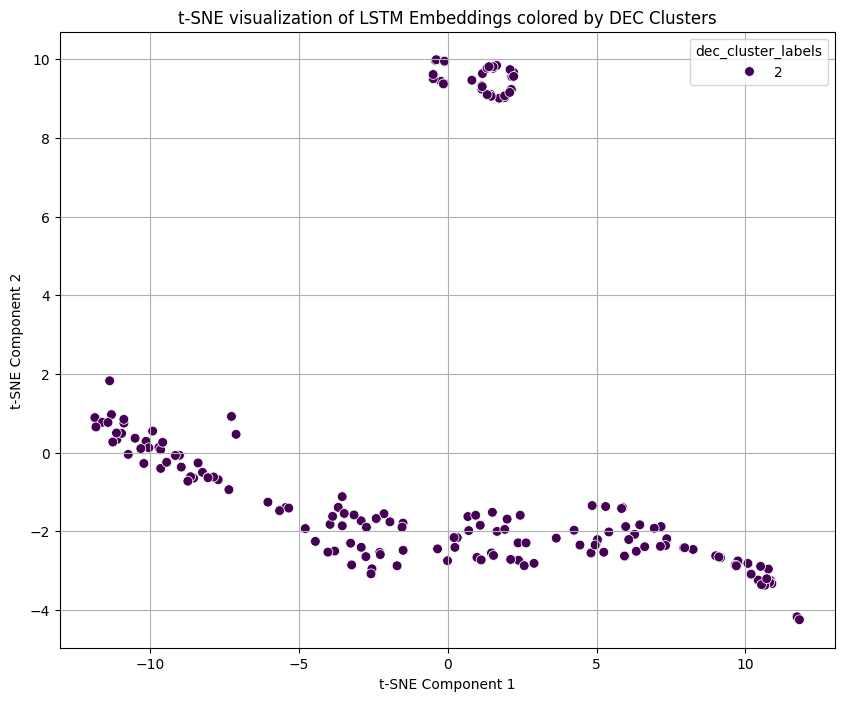

In [44]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# t-SNE dimensionality reduction on the LSTM embeddings
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
tsne_embeddings = tsne.fit_transform(conversation_embeddings_for_dec)

df_ready_for_clustering['tsne_component_1'] = tsne_embeddings[:, 0]
df_ready_for_clustering['tsne_component_2'] = tsne_embeddings[:, 1]

# Visualize the t-SNE embeddings, colored by the final DEC cluster labels
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='tsne_component_1',
    y='tsne_component_2',
    hue='dec_cluster_labels',
    palette='viridis', # or 'tab10', 'Set1', etc.
    data=df_ready_for_clustering,
    legend='full',
    s=50 # size of points
)
plt.title('t-SNE visualization of LSTM Embeddings colored by DEC Clusters')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()